## Dynamic-DeepHit — Competing Risks Survival Model with LSTM Encoder

Extends static DeepHit by adding an LSTM that processes **time-varying features** per loan-month:
- **Static features**: 9 loan/market features (BorrowerRate, FED rate, T-bill rate, unemployment rate, APR-FED spread, APR-T-bill spread, loan amount, term, payment)
- **Time-varying features**: FED rate path, T-bill rate path, unemployment rate, APR-FED spread, APR-T-bill spread, spread momentum, months remaining, month since origination
- **LSTM encoder** produces a temporal summary → fused with static features → DeepHit output
- **Key advantage**: captures temporal dynamics (seasoning curve, rate environment changes, labor market shifts) that static DeepHit misses

In [10]:
# ===== 1. DATA PREP: Loan-level survival format (same as DeepHit.ipynb) =====
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('../data/prosperLoanData.csv')
fed_df = pd.read_csv('../data/FEDFUNDS.csv')
tb3ms_df = pd.read_csv('../data/TB3MS.csv')
unrate_df = pd.read_csv('../data/UNRATE.csv')

# Clean dates
df['ListingCreationDate'] = pd.to_datetime(df['ListingCreationDate'], format='mixed')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], format='mixed')
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'], format='mixed')

# Remove cancelled loans
df = df[~df['LoanStatus'].isin(['Cancelled'])]

# Identify prepaid loans
df['Prepayment'] = (
    df['LoanStatus'].isin(['Completed']) &
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30 < df['Term'] - 1)
)

# Event type: 0=censored, 1=default, 2=prepay
def assign_event(row):
    if row['LoanStatus'] in ['Defaulted', 'Chargedoff']:
        return 1
    elif row['Prepayment']:
        return 2
    else:
        return 0

df['event'] = df.apply(assign_event, axis=1)

# Duration: months from origination to event or last observation
as_of_date = pd.to_datetime('2014-03-10')
df['duration'] = np.where(
    df['event'] > 0,
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1),
    ((as_of_date - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1)
)
df['duration'] = df['duration'].clip(upper=36).astype(int)

# FED rate at origination
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_monthly = fed_df.set_index('observation_date').resample('MS').first().ffill()
fed_dict = fed_monthly['FEDFUNDS'].to_dict()
df['orig_month'] = df['LoanOriginationDate'].dt.to_period('M').dt.to_timestamp()
df['fed_at_orig'] = df['orig_month'].map(fed_dict)

# T-bill rate at origination
tb3ms_df['observation_date'] = pd.to_datetime(tb3ms_df['observation_date'])
tb3ms_monthly = tb3ms_df.set_index('observation_date').resample('MS').first().ffill()
tb3ms_dict = tb3ms_monthly['TB3MS'].to_dict()
df['tb3ms_at_orig'] = df['orig_month'].map(tb3ms_dict)

# Unemployment rate at origination
unrate_df['observation_date'] = pd.to_datetime(unrate_df['observation_date'])
unrate_monthly = unrate_df.set_index('observation_date').resample('MS').first().ffill()
unrate_dict = unrate_monthly['UNRATE'].to_dict()
df['unrate_at_orig'] = df['orig_month'].map(unrate_dict)

# ---- Feature engineering (loan/market features only — no borrower features) ----
df['apr_fed_spread'] = df['BorrowerRate'] - df['fed_at_orig'] / 100
df['apr_tbill_spread'] = df['BorrowerRate'] - df['tb3ms_at_orig'] / 100
df['loan_amount_log'] = np.log1p(df['LoanOriginalAmount'])
df['monthly_payment'] = df['MonthlyLoanPayment']

feature_cols = [
    'BorrowerRate', 'fed_at_orig', 'tb3ms_at_orig', 'unrate_at_orig',
    'apr_fed_spread', 'apr_tbill_spread',
    'loan_amount_log', 'Term', 'monthly_payment'
]

surv_df = df[feature_cols + ['duration', 'event', 'LoanOriginationDate', 'orig_month']].dropna()
surv_df = surv_df[surv_df['BorrowerRate'] > 0].reset_index(drop=True)

print(f'Loans: {len(surv_df):,}')
print(f'Events: {surv_df["event"].value_counts().to_dict()}')
print(f'Duration range: {surv_df["duration"].min()} - {surv_df["duration"].max()}')
print(f'Features: {len(feature_cols)}')
print(f'Year range: {surv_df["LoanOriginationDate"].dt.year.min()} - {surv_df["LoanOriginationDate"].dt.year.max()}')

Loans: 113,924
Events: {0: 69435, 2: 27480, 1: 17009}
Duration range: 1 - 36
Features: 9
Year range: 2005 - 2014


In [11]:
# ===== 2. BUILD TIME-VARYING SEQUENCE TENSORS =====
# For each loan, construct a sequence [T_obs, n_tv] of monthly time-varying features:
#   - fed_rate: Federal Funds Rate at that calendar month
#   - tb3ms_rate: 3-Month T-bill rate at that calendar month
#   - unrate: Unemployment rate at that calendar month
#   - apr_fed_spread: BorrowerRate - FED rate (refinancing incentive, time-varying)
#   - apr_tbill_spread: BorrowerRate - T-bill rate (time-varying)
#   - spread_change_3m: 3-month momentum of the APR-FED spread
#   - months_remaining: Term - month_since_orig
#   - month_since_orig: explicit temporal position (1, 2, ..., T)

from dateutil.relativedelta import relativedelta

MAX_SEQ_LEN = 36
N_TV_FEATURES = 8

# Precompute rate series as sorted arrays for fast lookup
fed_series = fed_monthly['FEDFUNDS'].sort_index()
tb3ms_series = tb3ms_monthly['TB3MS'].sort_index()
unrate_series = unrate_monthly['UNRATE'].sort_index()

def get_rate(series, rate_dict, date):
    """Get rate for a given month-start date, with forward fill."""
    if date in rate_dict:
        return rate_dict[date]
    mask = series.index <= date
    if mask.any():
        return series[mask].iloc[-1]
    return series.iloc[0]

# Build sequences vectorized per loan
n_loans = len(surv_df)
x_seq = np.zeros((n_loans, MAX_SEQ_LEN, N_TV_FEATURES), dtype=np.float32)
seq_lengths = np.zeros(n_loans, dtype=np.int64)

for i in range(n_loans):
    row = surv_df.iloc[i]
    orig = row['orig_month']
    duration = int(row['duration'])
    borrower_rate = row['BorrowerRate']
    term = row['Term']
    
    seq_lengths[i] = duration
    
    for t in range(duration):
        month_idx = t + 1  # 1-indexed month since origination
        current_month = orig + relativedelta(months=month_idx)
        
        # Time-varying macro features
        fed_rate = get_rate(fed_series, fed_dict, current_month)
        tb3ms_rate = get_rate(tb3ms_series, tb3ms_dict, current_month)
        unrate = get_rate(unrate_series, unrate_dict, current_month)
        apr_fed_spread = borrower_rate - fed_rate / 100
        apr_tbill_spread = borrower_rate - tb3ms_rate / 100
        
        # 3-month spread momentum
        if month_idx >= 3:
            past_month = orig + relativedelta(months=month_idx - 3)
            past_fed = get_rate(fed_series, fed_dict, past_month)
            past_spread = borrower_rate - past_fed / 100
            spread_change_3m = apr_fed_spread - past_spread
        else:
            spread_change_3m = 0.0
        
        months_remaining = term - month_idx
        
        x_seq[i, t, 0] = fed_rate
        x_seq[i, t, 1] = tb3ms_rate
        x_seq[i, t, 2] = unrate
        x_seq[i, t, 3] = apr_fed_spread
        x_seq[i, t, 4] = apr_tbill_spread
        x_seq[i, t, 5] = spread_change_3m
        x_seq[i, t, 6] = months_remaining
        x_seq[i, t, 7] = month_idx

    if (i + 1) % 5000 == 0:
        print(f'  Processed {i+1:,}/{n_loans:,} loans...')

print(f'\nSequence tensor shape: {x_seq.shape}')
print(f'Time-varying features: {N_TV_FEATURES}')
print(f'  [fed_rate, tb3ms_rate, unrate, apr_fed_spread, apr_tbill_spread, spread_change_3m, months_remaining, month_since_orig]')
print(f'Lengths: min={seq_lengths.min()}, max={seq_lengths.max()}, mean={seq_lengths.mean():.1f}')
print(f'\nSample sequence (loan 0, first 5 months):')
for t in range(min(5, seq_lengths[0])):
    print(f'  Month {t+1}: {x_seq[0, t, :].tolist()}')

  Processed 5,000/113,924 loans...
  Processed 10,000/113,924 loans...
  Processed 15,000/113,924 loans...
  Processed 20,000/113,924 loans...
  Processed 25,000/113,924 loans...
  Processed 30,000/113,924 loans...
  Processed 35,000/113,924 loans...
  Processed 40,000/113,924 loans...
  Processed 45,000/113,924 loans...
  Processed 50,000/113,924 loans...
  Processed 55,000/113,924 loans...
  Processed 60,000/113,924 loans...
  Processed 65,000/113,924 loans...
  Processed 70,000/113,924 loans...
  Processed 75,000/113,924 loans...
  Processed 80,000/113,924 loans...
  Processed 85,000/113,924 loans...
  Processed 90,000/113,924 loans...
  Processed 95,000/113,924 loans...
  Processed 100,000/113,924 loans...
  Processed 105,000/113,924 loans...
  Processed 110,000/113,924 loans...

Sequence tensor shape: (113924, 36, 8)
Time-varying features: 8
  [fed_rate, tb3ms_rate, unrate, apr_fed_spread, apr_tbill_spread, spread_change_3m, months_remaining, month_since_orig]
Lengths: min=1, max=

In [12]:
# ===== 3. TRAIN/VAL/TEST SPLIT + SCALING =====
# Train: 2005-2010 | Validate: 2011 | Test: 2012-2014
# 1-year gap between train and test to prevent data leakage
from sklearn.preprocessing import StandardScaler
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

train_mask = surv_df['LoanOriginationDate'].dt.year <= 2010
val_mask   = surv_df['LoanOriginationDate'].dt.year == 2011
test_mask  = surv_df['LoanOriginationDate'].dt.year >= 2012

train_idx = np.where(train_mask)[0]
val_idx   = np.where(val_mask)[0]
test_idx  = np.where(test_mask)[0]

# --- Static features ---
static_scaler = StandardScaler()
x_train_static = static_scaler.fit_transform(surv_df.loc[train_mask, feature_cols]).astype('float32')
x_val_static   = static_scaler.transform(surv_df.loc[val_mask, feature_cols]).astype('float32')
x_test_static  = static_scaler.transform(surv_df.loc[test_mask, feature_cols]).astype('float32')

# --- Sequence features ---
x_train_seq = x_seq[train_idx]
x_val_seq   = x_seq[val_idx]
x_test_seq  = x_seq[test_idx]
train_lengths = seq_lengths[train_idx]
val_lengths   = seq_lengths[val_idx]
test_lengths  = seq_lengths[test_idx]

# Scale sequence features (fit on train only)
seq_scaler = StandardScaler()
train_flat = x_train_seq.reshape(-1, N_TV_FEATURES)
train_time_mask = np.zeros(len(train_idx) * MAX_SEQ_LEN, dtype=bool)
for i, length in enumerate(train_lengths):
    train_time_mask[i * MAX_SEQ_LEN: i * MAX_SEQ_LEN + length] = True

seq_scaler.fit(train_flat[train_time_mask])

# Transform all sets
x_train_seq_scaled = seq_scaler.transform(train_flat).reshape(-1, MAX_SEQ_LEN, N_TV_FEATURES).astype('float32')
val_flat = x_val_seq.reshape(-1, N_TV_FEATURES)
x_val_seq_scaled = seq_scaler.transform(val_flat).reshape(-1, MAX_SEQ_LEN, N_TV_FEATURES).astype('float32')
test_flat = x_test_seq.reshape(-1, N_TV_FEATURES)
x_test_seq_scaled = seq_scaler.transform(test_flat).reshape(-1, MAX_SEQ_LEN, N_TV_FEATURES).astype('float32')

# Zero out padding positions after scaling
for i, length in enumerate(train_lengths):
    x_train_seq_scaled[i, length:, :] = 0.0
for i, length in enumerate(val_lengths):
    x_val_seq_scaled[i, length:, :] = 0.0
for i, length in enumerate(test_lengths):
    x_test_seq_scaled[i, length:, :] = 0.0

# --- Targets ---
y_train_dur = surv_df.loc[train_mask, 'duration'].values
y_train_evt = surv_df.loc[train_mask, 'event'].values
y_val_dur   = surv_df.loc[val_mask, 'duration'].values
y_val_evt   = surv_df.loc[val_mask, 'event'].values
y_test_dur  = surv_df.loc[test_mask, 'duration'].values
y_test_evt  = surv_df.loc[test_mask, 'event'].values

num_durations = 36
labtrans = LabTransDiscreteTime(num_durations)
y_train_dh = labtrans.fit_transform(y_train_dur.astype('float64'), y_train_evt.astype('float64'))
y_val_dh   = labtrans.transform(y_val_dur.astype('float64'), y_val_evt.astype('float64'))
y_test_dh  = labtrans.transform(y_test_dur.astype('float64'), y_test_evt.astype('float64'))
y_train_dh = (y_train_dh[0].astype('int64'), y_train_dh[1].astype('int64'))
y_val_dh   = (y_val_dh[0].astype('int64'), y_val_dh[1].astype('int64'))
y_test_dh  = (y_test_dh[0].astype('int64'), y_test_dh[1].astype('int64'))

# --- Lengths as float32 for torchtuples compatibility ---
train_lengths_f = train_lengths.reshape(-1, 1).astype('float32')
val_lengths_f   = val_lengths.reshape(-1, 1).astype('float32')
test_lengths_f  = test_lengths.reshape(-1, 1).astype('float32')

print(f'Train (≤2010): {len(train_idx):,} | Val (2011): {len(val_idx):,} | Test (≥2012): {len(test_idx):,}')
print(f'Static shape:   train={x_train_static.shape}, val={x_val_static.shape}, test={x_test_static.shape}')
print(f'Sequence shape: train={x_train_seq_scaled.shape}, val={x_val_seq_scaled.shape}, test={x_test_seq_scaled.shape}')
print(f'Train events: { {k: v for k, v in zip(*np.unique(y_train_evt, return_counts=True))} }')
print(f'Val events:   { {k: v for k, v in zip(*np.unique(y_val_evt, return_counts=True))} }')
print(f'Test events:  { {k: v for k, v in zip(*np.unique(y_test_evt, return_counts=True))} }')

Train (≤2010): 36,626 | Val (2011): 11,228 | Test (≥2012): 66,070
Static shape:   train=(36626, 9), val=(11228, 9), test=(66070, 9)
Sequence shape: train=(36626, 36, 8), val=(11228, 36, 8), test=(66070, 36, 8)
Train events: {np.int64(0): np.int64(9576), np.int64(1): np.int64(11904), np.int64(2): np.int64(15146)}
Val events:   {np.int64(0): np.int64(4121), np.int64(1): np.int64(2145), np.int64(2): np.int64(4962)}
Test events:  {np.int64(0): np.int64(55738), np.int64(1): np.int64(2960), np.int64(2): np.int64(7372)}


In [13]:
# ===== 4. DYNAMIC-DEEPHIT NETWORK =====
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit

num_risks = 2  # default + prepay

class DynamicDeepHitNet(nn.Module):
    """
    LSTM encoder for time-varying features + MLP for static features → DeepHit output.
    
    Inputs (as 3-tuple from torchtuples):
        x_static:  [batch, 9]      - static loan/market features
        x_seq:     [batch, 36, 8]  - time-varying features per month
        x_lengths: [batch, 1]      - actual sequence lengths (float32, cast to long internally)
    
    Output: [batch, 2, 36] - PMF over time for each competing risk
    """
    def __init__(self, n_static=9, n_tv=8, lstm_hidden=48, 
                 num_risks=2, num_durations=36):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_tv, hidden_size=lstm_hidden,
            num_layers=1, batch_first=True
        )
        self.lstm_drop = nn.Dropout(0.2)
        
        combined_dim = n_static + lstm_hidden  # 9 + 48 = 57
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, num_risks * num_durations),
        )
        self.num_risks = num_risks
        self.num_durations = num_durations
    
    def forward(self, x_static, x_seq, x_lengths):
        lengths = x_lengths.view(-1).long().clamp(min=1)
        
        packed = nn.utils.rnn.pack_padded_sequence(
            x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, (h_n, _) = self.lstm(packed)
        h = self.lstm_drop(h_n.squeeze(0))  # [B, 48]
        
        combined = torch.cat([x_static, h], dim=1)  # [B, 57]
        out = self.mlp(combined)
        return out.view(-1, self.num_risks, self.num_durations)

net = DynamicDeepHitNet(
    n_static=len(feature_cols),
    n_tv=N_TV_FEATURES,
    lstm_hidden=48,
    num_risks=num_risks,
    num_durations=labtrans.out_features,
)

model = DeepHit(
    net,
    tt.optim.Adam(lr=0.0005),
    duration_index=labtrans.cuts,
    alpha=0.5,
    sigma=0.1,
)

print(f'Model params: {sum(p.numel() for p in net.parameters()):,}')
print(f'  LSTM params: {sum(p.numel() for n, p in net.named_parameters() if "lstm" in n):,}')
print(f'  MLP params:  {sum(p.numel() for n, p in net.named_parameters() if "mlp" in n):,}')
print(f'Input: {len(feature_cols)} static + {N_TV_FEATURES} time-varying features')
print(f'Output shape: [batch, {num_risks}, {labtrans.out_features}]')
print(net)

Model params: 31,720
  LSTM params: 11,136
  MLP params:  20,584
Input: 9 static + 8 time-varying features
Output shape: [batch, 2, 36]
DynamicDeepHitNet(
  (lstm): LSTM(8, 48, batch_first=True)
  (lstm_drop): Dropout(p=0.2, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=57, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=72, bias=True)
  )
)


0:	[7s / 7s],		train_loss: 2.3386,	val_loss: 1.9708
1:	[7s / 15s],		train_loss: 2.0339,	val_loss: 1.5756
2:	[7s / 22s],		train_loss: 1.8262,	val_loss: 1.3161
3:	[7s / 29s],		train_loss: 1.6803,	val_loss: 1.2391
4:	[7s / 37s],		train_loss: 1.5481,	val_loss: 1.1579
5:	[7s / 44s],		train_loss: 1.4147,	val_loss: 1.0808
6:	[7s / 51s],		train_loss: 1.2742,	val_loss: 1.0075
7:	[7s / 58s],		train_loss: 1.1304,	val_loss: 0.9196
8:	[7s / 1m:6s],		train_loss: 1.0050,	val_loss: 0.8444
9:	[7s / 1m:13s],		train_loss: 0.9021,	val_loss: 0.7796
10:	[7s / 1m:20s],		train_loss: 0.8243,	val_loss: 0.7426
11:	[7s / 1m:27s],		train_loss: 0.7624,	val_loss: 0.6791
12:	[7s / 1m:35s],		train_loss: 0.7083,	val_loss: 0.6458
13:	[7s / 1m:42s],		train_loss: 0.6621,	val_loss: 0.6163
14:	[7s / 1m:49s],		train_loss: 0.6258,	val_loss: 0.6192
15:	[7s / 1m:57s],		train_loss: 0.5835,	val_loss: 0.5553
16:	[7s / 2m:4s],		train_loss: 0.5472,	val_loss: 0.5333
17:	[7s / 2m:11s],		train_loss: 0.5142,	val_loss: 0.5364
18:	[7s / 2

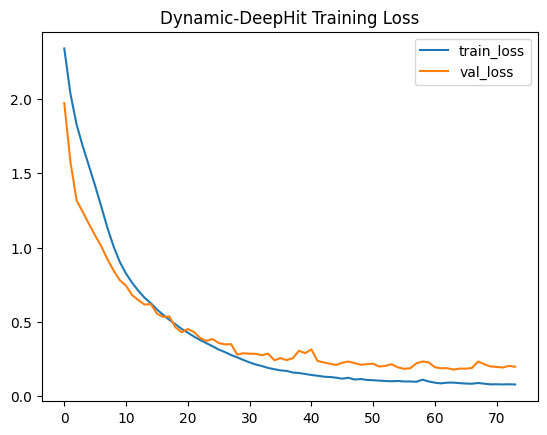

In [14]:
# ===== 5. TRAIN =====
import matplotlib.pyplot as plt

# Pack inputs as 3-tuple for torchtuples
x_train_tuple = (x_train_static, x_train_seq_scaled, train_lengths_f)
x_val_tuple   = (x_val_static, x_val_seq_scaled, val_lengths_f)
x_test_tuple  = (x_test_static, x_test_seq_scaled, test_lengths_f)

# Early stopping on validation set (2011), not test set
callbacks = [
    tt.callbacks.EarlyStopping(patience=10),
    tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4),
]

log = model.fit(
    x_train_tuple, y_train_dh,
    batch_size=512,
    epochs=100,
    callbacks=callbacks,
    val_data=(x_val_tuple, y_val_dh),
    verbose=True
)

fig, ax = plt.subplots()
log.plot(ax=ax)
ax.set_title('Dynamic-DeepHit Training Loss')
plt.show()

In [15]:
# ===== 6. EVALUATE (on test set: 2012-2014) =====
from pycox.evaluation import EvalSurv

# Fix scipy compatibility
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

# Get CIF predictions
cif = model.predict_cif(x_test_tuple)

# --- C-index ---
print('=== C-index (time-dependent) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    c_idx = ev.concordance_td()
    print(f'  {risk_name} C-index: {c_idx:.3f}')

# --- Brier Score ---
print('\n=== Integrated Brier Score ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    time_grid = np.linspace(1, 36, 36)
    ibs = ev.integrated_brier_score(time_grid)
    print(f'  {risk_name} IBS: {ibs:.4f} (lower is better)')

# --- Lift chart ---
print('\n=== Lift by Decile (at t=12 months) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    t12_idx = 11
    pred_risk = cif[risk_idx][t12_idx, :]
    actual_by_t12 = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)
    
    order = np.argsort(-pred_risk)
    n = len(order)
    decile_size = n // 10
    baseline_rate = actual_by_t12.mean()
    
    print(f'  {risk_name} (baseline rate: {baseline_rate:.4f}):')
    for d in range(10):
        idx = order[d * decile_size:(d + 1) * decile_size]
        rate = actual_by_t12[idx].mean()
        lift = rate / baseline_rate if baseline_rate > 0 else 0
        bar = '#' * int(lift * 5)
        print(f'    Decile {d+1:2d}: rate={rate:.4f}  lift={lift:.2f}x  {bar}')

print(f'\nCIF shape: {cif[0].shape} (time_steps x loans)')

=== C-index (time-dependent) ===
  Default C-index: 0.665
  Prepay C-index: 0.574

=== Integrated Brier Score ===
  Default IBS: 0.0400 (lower is better)
  Prepay IBS: 0.3991 (lower is better)

=== Lift by Decile (at t=12 months) ===
  Default (baseline rate: 0.0264):
    Decile  1: rate=0.0610  lift=2.31x  ###########
    Decile  2: rate=0.0851  lift=3.22x  ################
    Decile  3: rate=0.0064  lift=0.24x  #
    Decile  4: rate=0.0002  lift=0.01x  
    Decile  5: rate=0.0048  lift=0.18x  
    Decile  6: rate=0.0392  lift=1.49x  #######
    Decile  7: rate=0.0492  lift=1.86x  #########
    Decile  8: rate=0.0030  lift=0.11x  
    Decile  9: rate=0.0151  lift=0.57x  ##
    Decile 10: rate=0.0000  lift=0.00x  
  Prepay (baseline rate: 0.0815):
    Decile  1: rate=0.1002  lift=1.23x  ######
    Decile  2: rate=0.0655  lift=0.80x  ####
    Decile  3: rate=0.0717  lift=0.88x  ####
    Decile  4: rate=0.1044  lift=1.28x  ######
    Decile  5: rate=0.0946  lift=1.16x  #####
    Decile 

In [16]:
# ===== 6b. APPLES-TO-APPLES METRICS (PR-AUC & KS) =====
from sklearn.metrics import average_precision_score
from scipy.stats import ks_2samp

print('=== PR-AUC (Precision-Recall AUC) ===')
print('  Using CIF at t=36 as risk score, loan-level binary outcome as label\n')

for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][-1, :]  # CIF at t=36 for all test loans
    actual = (y_test_evt == risk_idx + 1).astype(int)
    base_rate = actual.mean()
    
    pr_auc = average_precision_score(actual, pred_risk)
    print(f'  {risk_name} PR-AUC: {pr_auc:.3f}  (base rate: {base_rate:.4f})')

print('\n  At t=12:')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][11, :]  # CIF at t=12
    actual = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)
    base_rate = actual.mean()
    
    pr_auc = average_precision_score(actual, pred_risk)
    print(f'  {risk_name} PR-AUC (t=12): {pr_auc:.3f}  (base rate: {base_rate:.4f})')

# --- KS Statistic ---
print('\n=== KS Statistic ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    pred_risk = cif[risk_idx][-1, :]
    event_scores = pred_risk[y_test_evt == risk_idx + 1]
    non_event_scores = pred_risk[y_test_evt != risk_idx + 1]
    
    ks_stat, ks_pval = ks_2samp(event_scores, non_event_scores)
    print(f'  {risk_name} KS: {ks_stat:.3f}  (p={ks_pval:.2e})')

=== PR-AUC (Precision-Recall AUC) ===
  Using CIF at t=36 as risk score, loan-level binary outcome as label

  Default PR-AUC: 0.059  (base rate: 0.0448)
  Prepay PR-AUC: 0.133  (base rate: 0.1116)

  At t=12:
  Default PR-AUC (t=12): 0.053  (base rate: 0.0264)
  Prepay PR-AUC (t=12): 0.111  (base rate: 0.0815)

=== KS Statistic ===
  Default KS: 0.209  (p=2.42e-108)
  Prepay KS: 0.093  (p=4.34e-50)


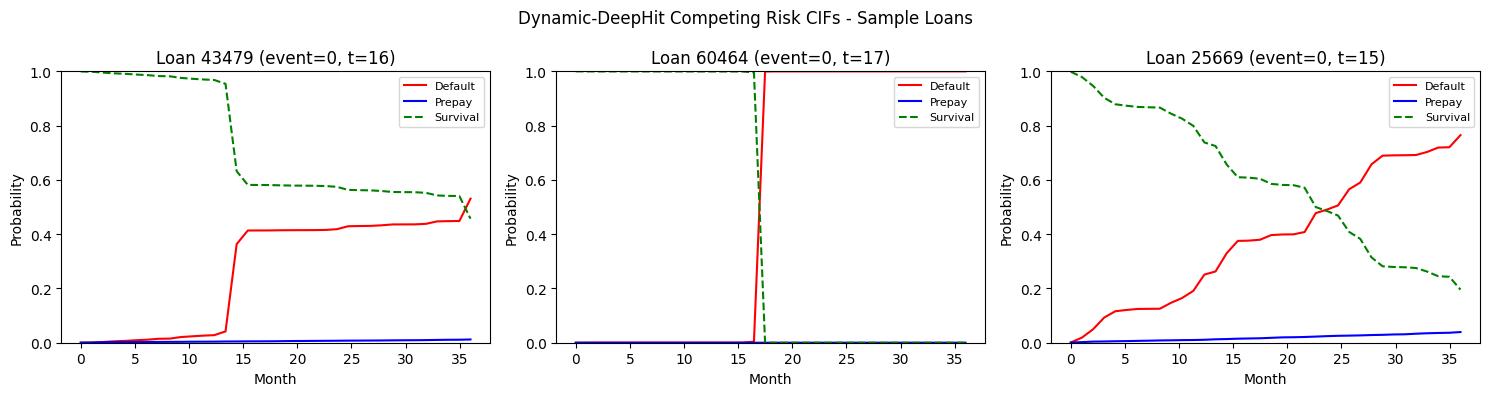

In [17]:
# ===== 7. VISUALIZE: Sample loan CIFs =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_grid = labtrans.cuts

for i, ax in enumerate(axes):
    idx = np.random.randint(len(x_test_static))
    ax.plot(time_grid, cif[0][:, idx], label='Default', color='red')
    ax.plot(time_grid, cif[1][:, idx], label='Prepay', color='blue')
    ax.plot(time_grid, 1 - cif[0][:, idx] - cif[1][:, idx], label='Survival', color='green', ls='--')
    ax.set_xlabel('Month')
    ax.set_ylabel('Probability')
    ax.set_title(f'Loan {idx} (event={y_test_evt[idx]}, t={y_test_dur[idx]})')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('Dynamic-DeepHit Competing Risk CIFs - Sample Loans')
plt.tight_layout()
plt.show()